In [1]:
"""
OptiCrop - Model Evaluation Script
Evaluates model performance with detailed metrics
"""

import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📊 OPTICROP - MODEL EVALUATION")
print("="*70)
print("✅ Libraries imported successfully!")

📊 OPTICROP - MODEL EVALUATION
✅ Libraries imported successfully!


In [6]:
# Get the directory where this notebook is located
BASE_DIR = os.getcwd()
print(f"📁 Current directory: {BASE_DIR}")

# CORRECT PATHS - Note the extra 'Model' folder!
model_path = os.path.join(BASE_DIR, 'Model', 'models', 'crop_model.pkl')
scaler_path = os.path.join(BASE_DIR, 'Model', 'models', 'scaler.pkl')

print(f"📁 Model path: {model_path}")
print(f"📁 Scaler path: {scaler_path}")

📁 Current directory: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase
📁 Model path: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase\Model\models\crop_model.pkl
📁 Scaler path: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase\Model\models\scaler.pkl


In [8]:
print("\n📂 Loading model and dataset...")

# Load model
try:
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    print(f"✅ Model loaded from: {model_path}")
    print(f"📊 Model type: {type(model).__name__}")
    print(f"🌾 Number of crops: {len(model.classes_)}")
except FileNotFoundError:
    print(f"❌ Model not found at: {model_path}")
    model = None
except Exception as e:
    print(f"❌ Error loading model: {e}")
    model = None

# Load scaler
try:
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    print(f"✅ Scaler loaded from: {scaler_path}")
except FileNotFoundError:
    print(f"❌ Scaler not found at: {scaler_path}")
    scaler = None

# Load dataset - FIXED PATH (go up one level)
dataset_path = os.path.join(BASE_DIR, '..', 'Dataset', 'Crop_recommendation.csv')
try:
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset loaded from: {dataset_path}")
    print(f"📊 Dataset: {len(df)} rows, {len(df.columns)} columns")
except FileNotFoundError:
    print(f"❌ Dataset not found at: {dataset_path}")
    df = None

if model is not None and scaler is not None and df is not None:
    print("\n✅ All files loaded successfully!")
    print(f"📊 Dataset: {len(df)} rows")
    print(f"📊 Model type: {type(model).__name__}")
    print(f"🌾 Number of crops: {len(model.classes_)}")
else:
    print("\n⚠️ Some files failed to load!")
    if model is None:
        print("   - ❌ Model not loaded")
    if scaler is None:
        print("   - ❌ Scaler not loaded")
    if df is None:
        print("   - ❌ Dataset not loaded")


📂 Loading model and dataset...
✅ Model loaded from: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase\Model\models\crop_model.pkl
📊 Model type: RandomForestClassifier
🌾 Number of crops: 22
✅ Scaler loaded from: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase\Model\models\scaler.pkl
✅ Dataset loaded from: C:\Users\sasi chintada\OptiCrop\5. Project_Development_Phase\..\Dataset\Crop_recommendation.csv
📊 Dataset: 2200 rows, 8 columns

✅ All files loaded successfully!
📊 Dataset: 2200 rows
📊 Model type: RandomForestClassifier
🌾 Number of crops: 22


In [9]:
if df is not None and model is not None and scaler is not None:
    print("\n📊 Preparing data...")

    X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
    y = df['label']
    
    print(f"   Features shape: {X.shape}")
    print(f"   Target shape: {y.shape}")

    X_scaled = scaler.transform(X)
    print("   ✅ Features scaled successfully!")
    print(f"   Scaled features shape: {X_scaled.shape}")
else:
    print("❌ Cannot prepare data - missing files!")


📊 Preparing data...
   Features shape: (2200, 7)
   Target shape: (2200,)
   ✅ Features scaled successfully!
   Scaled features shape: (2200, 7)


In [10]:
if model is not None and X_scaled is not None:
    print("\n🤖 Making predictions...")
    y_pred = model.predict(X_scaled)

    accuracy = accuracy_score(y, y_pred) * 100
    precision = precision_score(y, y_pred, average='weighted') * 100
    recall = recall_score(y, y_pred, average='weighted') * 100
    f1 = f1_score(y, y_pred, average='weighted') * 100

    print(f"\n📈 ACCURACY METRICS:")
    print(f"   ✅ Accuracy:  {accuracy:.2f}%")
    print(f"   ✅ Precision: {precision:.2f}%")
    print(f"   ✅ Recall:    {recall:.2f}%")
    print(f"   ✅ F1-Score:  {f1:.2f}%")
else:
    print("❌ Cannot calculate metrics - model not loaded!")


🤖 Making predictions...

📈 ACCURACY METRICS:
   ✅ Accuracy:  99.86%
   ✅ Precision: 99.87%
   ✅ Recall:    99.86%
   ✅ F1-Score:  99.86%


In [11]:
if model is not None and X_scaled is not None:
    print("\n📋 Classification Report:")
    print("-"*60)
    print(classification_report(y, y_pred))
else:
    print("❌ Cannot generate classification report - model not loaded!")


📋 Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       100
      banana       1.00      1.00      1.00       100
   blackgram       1.00      1.00      1.00       100
    chickpea       1.00      1.00      1.00       100
     coconut       1.00      1.00      1.00       100
      coffee       1.00      1.00      1.00       100
      cotton       1.00      1.00      1.00       100
      grapes       1.00      1.00      1.00       100
        jute       0.98      1.00      0.99       100
 kidneybeans       1.00      1.00      1.00       100
      lentil       0.99      1.00      1.00       100
       maize       1.00      1.00      1.00       100
       mango       1.00      1.00      1.00       100
   mothbeans       1.00      0.99      0.99       100
    mungbean       1.00      1.00      1.00       100
   muskmelon       1.00      1.00      1.00     


📊 Confusion Matrix Shape: (22, 22)
✅ Saved confusion matrix to 'results/confusion_matrix.png'


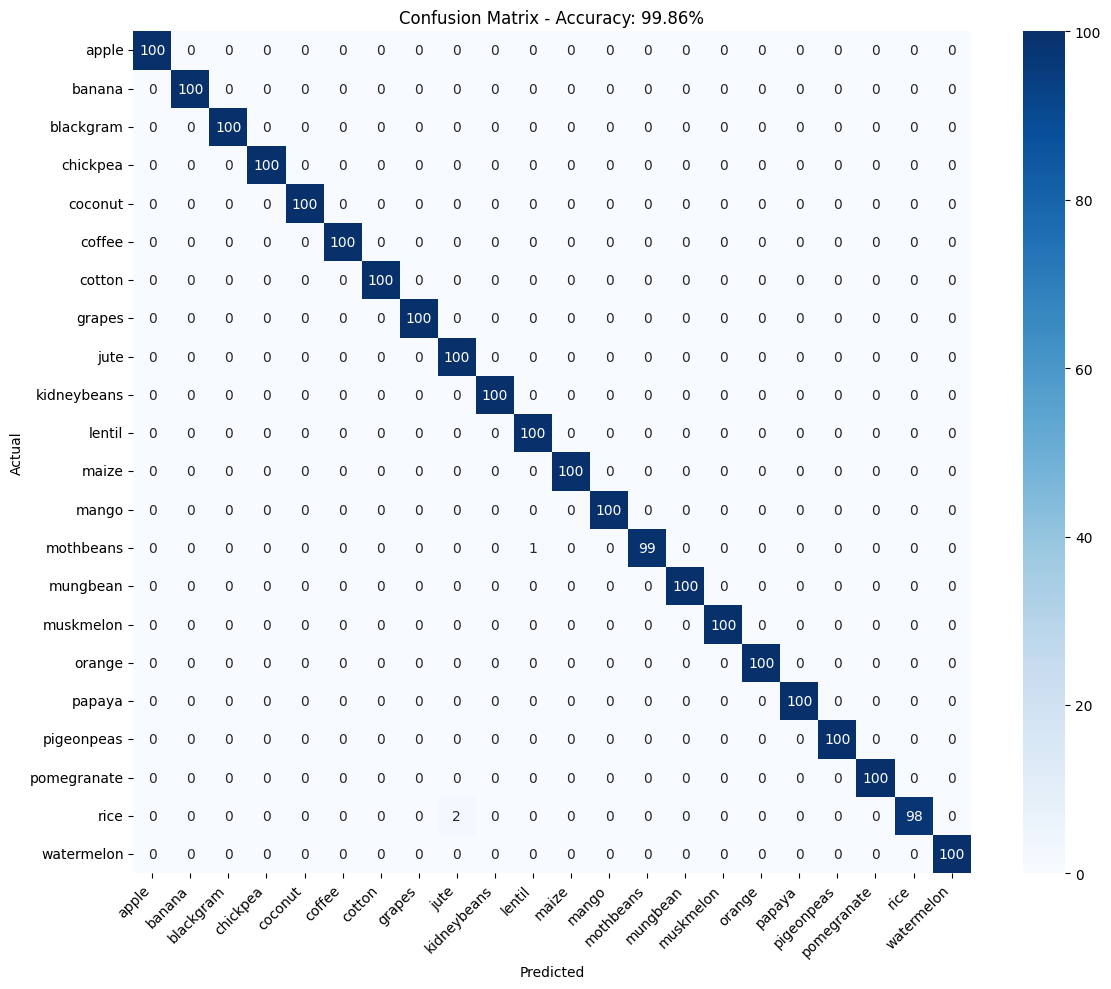

In [12]:
if model is not None and X_scaled is not None:
    cm = confusion_matrix(y, y_pred)
    print(f"\n📊 Confusion Matrix Shape: {cm.shape}")
    
    # Plot Confusion Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, 
                yticklabels=model.classes_)
    plt.title(f'Confusion Matrix - Accuracy: {accuracy:.2f}%')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    os.makedirs('results', exist_ok=True)
    plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("✅ Saved confusion matrix to 'results/confusion_matrix.png'")
    plt.show()
else:
    print("❌ Cannot plot confusion matrix - model not loaded!")

In [13]:
if model is not None and X_scaled is not None:
    print("\n🔄 Cross-Validation (5-Fold):")
    cv_scores = cross_val_score(model, X_scaled, y, cv=5)
    print(f"   Scores: {cv_scores}")
    print(f"   Mean: {cv_scores.mean()*100:.2f}%")
    print(f"   Std: {cv_scores.std()*100:.2f}%")
else:
    print("❌ Cannot run cross-validation - model not loaded!")


🔄 Cross-Validation (5-Fold):
   Scores: [0.99772727 0.99318182 0.99772727 0.99545455 0.98863636]
   Mean: 99.45%
   Std: 0.34%



📊 Feature Importance:
   N           : 10.89%
   P           : 14.36%
   K           : 18.12%
   temperature : 7.57%
   humidity    : 21.13%
   ph          : 5.23%
   rainfall    : 22.70%
✅ Saved feature importance plot to 'results/feature_importance.png'


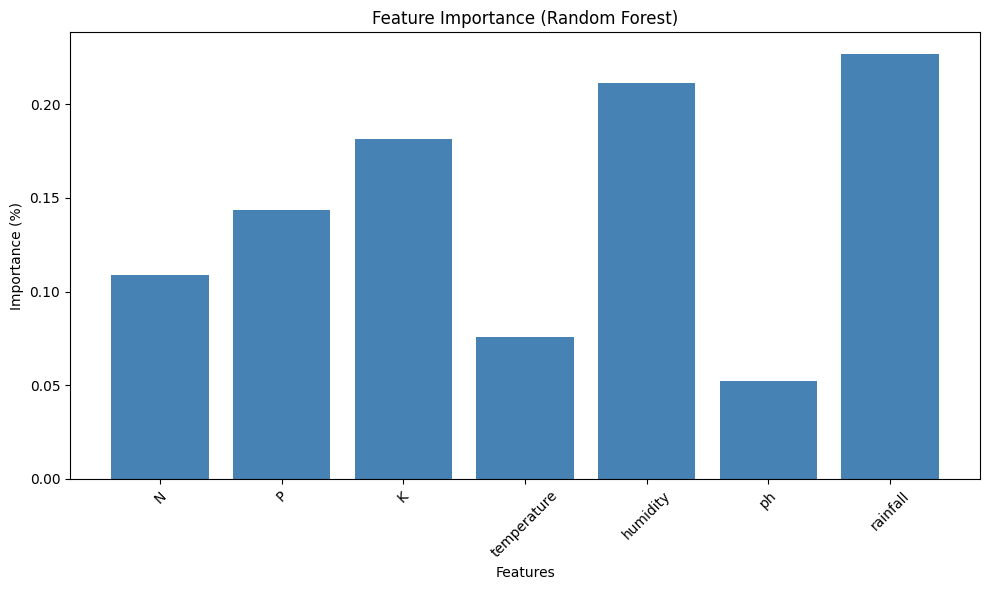

In [14]:
if model is not None:
    print("\n📊 Feature Importance:")
    if hasattr(model, 'feature_importances_'):
        features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
        importance = model.feature_importances_
        
        # Print importance
        for name, imp in zip(features, importance):
            print(f"   {name:12}: {imp*100:.2f}%")
        
        # Plot feature importance
        plt.figure(figsize=(10, 6))
        plt.bar(features, importance, color='steelblue')
        plt.title('Feature Importance (Random Forest)')
        plt.xlabel('Features')
        plt.ylabel('Importance (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        os.makedirs('results', exist_ok=True)
        plt.savefig('results/feature_importance.png', dpi=300, bbox_inches='tight')
        print("✅ Saved feature importance plot to 'results/feature_importance.png'")
        plt.show()
    else:
        print("   Model doesn't have feature importance attribute")
else:
    print("❌ Cannot calculate feature importance - model not loaded!")

In [15]:
if model is not None and X_scaled is not None:
    print("\n💾 Saving results...")
    os.makedirs('results', exist_ok=True)

    try:
        with open('results/accuracy.txt', 'w', encoding='utf-8') as f:
            f.write("="*70 + "\n")
            f.write("OPTICROP - MODEL ACCURACY RESULTS\n")
            f.write("="*70 + "\n\n")
            f.write(f"Overall Accuracy   : {accuracy:.2f}%\n")
            f.write(f"Precision          : {precision:.2f}%\n")
            f.write(f"Recall             : {recall:.2f}%\n")
            f.write(f"F1-Score           : {f1:.2f}%\n\n")
            f.write("="*70 + "\n")
            f.write("CROSS-VALIDATION\n")
            f.write("="*70 + "\n")
            f.write(f"Mean CV Score    : {cv_scores.mean()*100:.2f}%\n")
            f.write(f"Std CV Score     : {cv_scores.std()*100:.2f}%\n\n")
            f.write("="*70 + "\n")
            f.write("FEATURE IMPORTANCE\n")
            f.write("="*70 + "\n")
            if hasattr(model, 'feature_importances_'):
                features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
                importance = model.feature_importances_
                for name, imp in zip(features, importance):
                    f.write(f"{name}: {imp*100:.2f}%\n")
        print("✅ Saved results to 'results/accuracy.txt'")
    except Exception as e:
        print(f"⚠️ Could not save to file: {e}")
else:
    print("❌ Cannot save results - model not loaded!")


💾 Saving results...
✅ Saved results to 'results/accuracy.txt'


In [16]:
print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)

if model is not None and X_scaled is not None:
    print(f"""
📊 SUMMARY:
   - Dataset: {len(df)} samples
   - Best Model: {type(model).__name__}
   - Accuracy: {accuracy:.2f}%
   - Precision: {precision:.2f}%
   - Recall: {recall:.2f}%
   - F1-Score: {f1:.2f}%
   - Cross-Validation: {cv_scores.mean()*100:.2f}% (±{cv_scores.std()*100:.2f}%)
   """)
else:
    print("⚠️ Evaluation incomplete - check model files!")


✅ EVALUATION COMPLETE!

📊 SUMMARY:
   - Dataset: 2200 samples
   - Best Model: RandomForestClassifier
   - Accuracy: 99.86%
   - Precision: 99.87%
   - Recall: 99.86%
   - F1-Score: 99.86%
   - Cross-Validation: 99.45% (±0.34%)
   
